DAy 3

imports and setup:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
from pathlib import Path

# Paths
BASE = Path(r"C:\Users\Hello\OneDrive\Desktop\Bluestock_internship\bluestock_mf_capstone")
PROCESSED = BASE / "data" / "processed"

# Plot style
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

print("✅ Libraries loaded")

Matplotlib is building the font cache; this may take a moment.


✅ Libraries loaded


Step 2 — Load all cleaned datasets

In [2]:
# Load all cleaned datasets
nav         = pd.read_csv(PROCESSED / "clean_nav.csv", parse_dates=["date"])
transactions= pd.read_csv(PROCESSED / "clean_transactions.csv", parse_dates=["transaction_date"])
performance = pd.read_csv(PROCESSED / "clean_performance.csv")
fund_master = pd.read_csv(PROCESSED / "clean_fund_master.csv")
aum         = pd.read_csv(PROCESSED / "clean_aum_by_fund_house.csv")
sip         = pd.read_csv(PROCESSED / "clean_monthly_sip_inflows.csv")
category    = pd.read_csv(PROCESSED / "clean_category_inflows.csv")
folio       = pd.read_csv(PROCESSED / "clean_industry_folio_count.csv")
portfolio   = pd.read_csv(PROCESSED / "clean_portfolio_holdings.csv")
benchmark   = pd.read_csv(PROCESSED / "clean_benchmark_indices.csv", parse_dates=["date"])

print("✅ All datasets loaded")
print(f"NAV rows: {len(nav)}")
print(f"Transactions rows: {len(transactions)}")
print(f"Funds: {len(fund_master)}")

✅ All datasets loaded
NAV rows: 64320
Transactions rows: 32778
Funds: 40


Chart 1 — NAV Trend Lines for 5 key funds

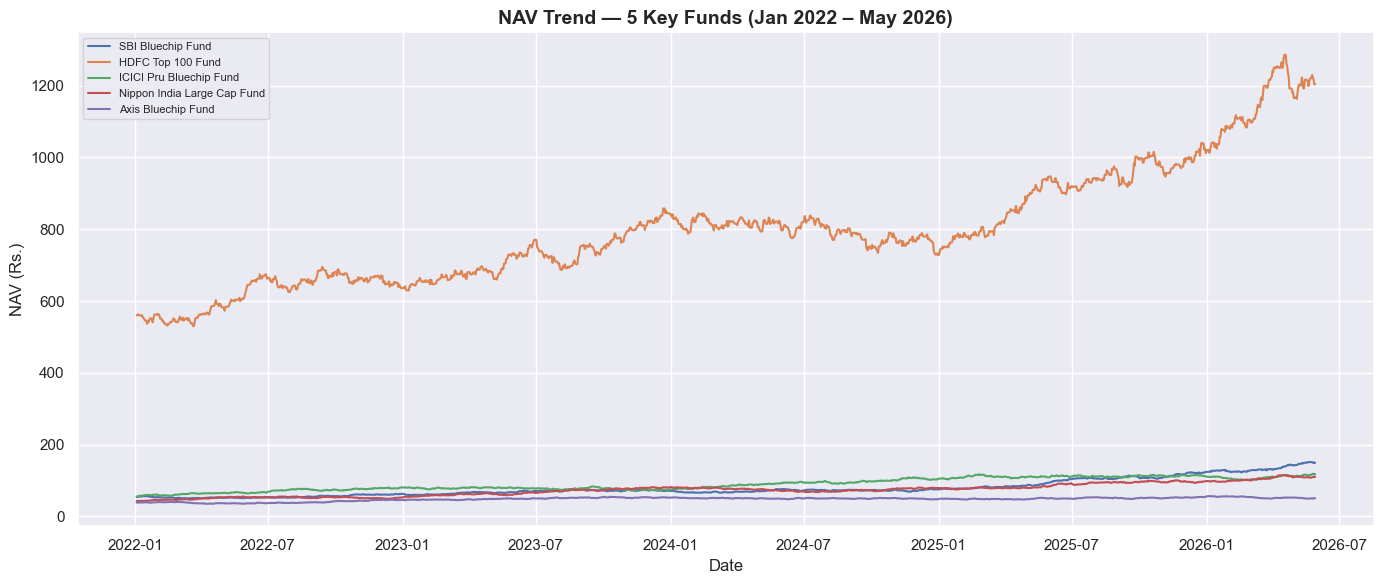

✅ Chart 1 saved


In [3]:
# Chart 1: NAV Trend for 5 selected funds
selected_funds = [119551, 125497, 120503, 118632, 119092]
fund_names = fund_master.set_index("amfi_code")["scheme_name"].to_dict()

fig, ax = plt.subplots(figsize=(14, 6))

for code in selected_funds:
    fund_nav = nav[nav["amfi_code"] == code]
    label = fund_names.get(code, str(code))
    # Shorten label for legend
    short_label = label.split("-")[0].strip()
    ax.plot(fund_nav["date"], fund_nav["nav"], label=short_label, linewidth=1.5)

ax.set_title("NAV Trend — 5 Key Funds (Jan 2022 – May 2026)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("NAV (Rs.)")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(BASE / "data" / "processed" / "chart_01_nav_trend.png", dpi=150)
plt.show()
print("✅ Chart 1 saved")

Chart 2 — AUM Growth by Fund House (Grouped Bar Chart)

In [5]:
print(aum.columns.tolist())
print(aum.head())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168


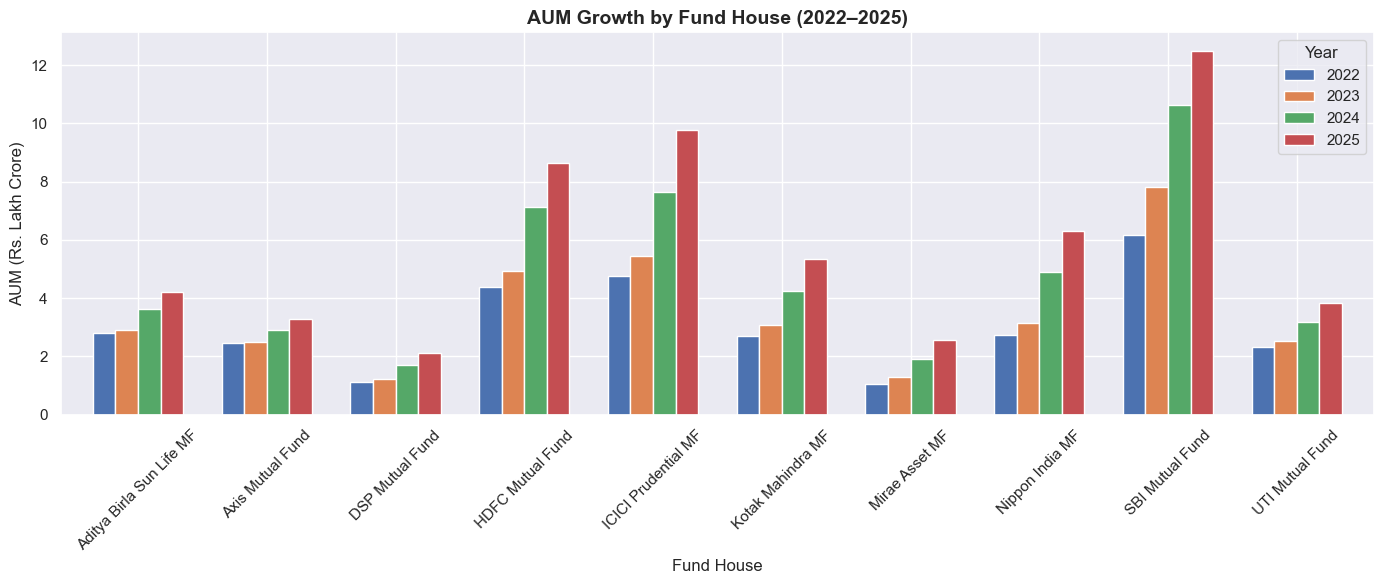

✅ Chart 2 saved


In [6]:
# Chart 2: AUM Growth by Fund House
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

fig, ax = plt.subplots(figsize=(14, 6))

aum_pivot = aum.pivot_table(index="fund_house", columns="year", values="aum_lakh_crore")
aum_pivot.plot(kind="bar", ax=ax, width=0.7)

ax.set_title("AUM Growth by Fund House (2022–2025)", fontsize=14, fontweight="bold")
ax.set_xlabel("Fund House")
ax.set_ylabel("AUM (Rs. Lakh Crore)")
ax.legend(title="Year")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(BASE / "data" / "processed" / "chart_02_aum_growth.png", dpi=150)
plt.show()
print("✅ Chart 2 saved")

AUM = Assets Under Management
In simple words — the total money that a mutual fund company is managing on behalf of investors.
Example:

SBI Mutual Fund manages Rs. 12.5 lakh crore worth of investments from lakhs of investors across India — that's their AUM.

Why it matters in this project:

Higher AUM = more trust, more investors, bigger fund house
We track AUM growth year by year to see which fund houses are growing
It's one of the key metrics on the dashboard`

Chart 3 — SIP Inflow Trend (Monthly)`

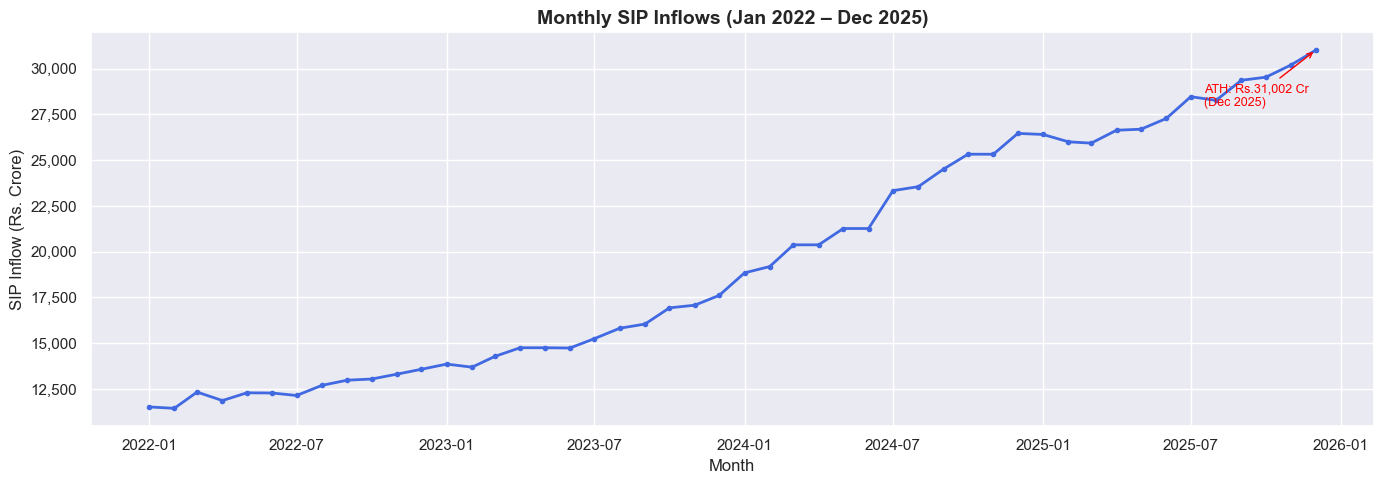

✅ Chart 3 saved


In [7]:
# Chart 3: SIP Inflow Time Series
sip["date"] = pd.to_datetime(sip["month"])

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(sip["date"], sip["sip_inflow_crore"], color="royalblue", linewidth=2, marker="o", markersize=3)

# Mark the all-time high
max_idx = sip["sip_inflow_crore"].idxmax()
ax.annotate("ATH: Rs.31,002 Cr\n(Dec 2025)",
            xy=(sip["date"][max_idx], sip["sip_inflow_crore"][max_idx]),
            xytext=(-80, -40), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", color="red"),
            fontsize=9, color="red")

ax.set_title("Monthly SIP Inflows (Jan 2022 – Dec 2025)", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("SIP Inflow (Rs. Crore)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(BASE / "data" / "processed" / "chart_03_sip_inflow.png", dpi=150)
plt.show()
print("✅ Chart 3 saved")

Chart 4 — Category-wise Inflow Heatmap

Check the column names first before calling them ow we get a key err

In [9]:
print(category.columns.tolist())
print(category.head())

['month', 'category', 'net_inflow_crore', 'date', 'month_label']
     month         category  net_inflow_crore       date month_label
0  2024-04        Large Cap            2413.0 2024-04-01    Apr 2024
1  2024-04          Mid Cap            3897.0 2024-04-01    Apr 2024
2  2024-04        Small Cap            3533.0 2024-04-01    Apr 2024
3  2024-04        Flexi Cap            4947.0 2024-04-01    Apr 2024
4  2024-04  Large & Mid Cap            4214.0 2024-04-01    Apr 2024


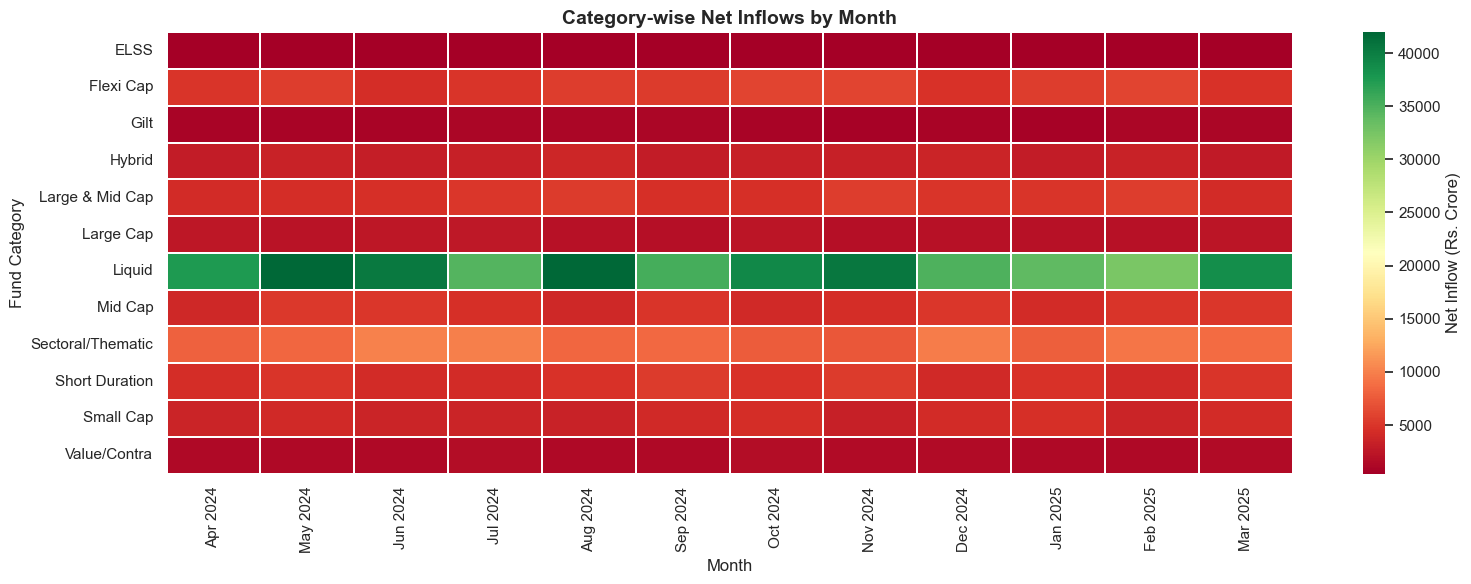

✅ Chart 4 saved


In [10]:
# Chart 4: Category-wise Inflow Heatmap
cat_pivot = category.pivot_table(
    index="category",
    columns="month_label",
    values="net_inflow_crore"
)

# Sort columns by date
cat_pivot = cat_pivot[sorted(cat_pivot.columns,
                     key=lambda x: pd.to_datetime(x, format="%b %Y"))]

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(cat_pivot, cmap="RdYlGn", linewidths=0.3,
            annot=False, ax=ax,
            cbar_kws={"label": "Net Inflow (Rs. Crore)"})

ax.set_title("Category-wise Net Inflows by Month", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Fund Category")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.savefig(BASE / "data" / "processed" / "chart_04_category_heatmap.png", dpi=150)
plt.show()
print("✅ Chart 4 saved")

Chart 5 — Investor Age Group Distribution (Pie + Box Plot)

C:\Users\Hello\AppData\Local\Temp\ipykernel_9788\1987823213.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sip_txn, x="age_group", y="amount_inr",


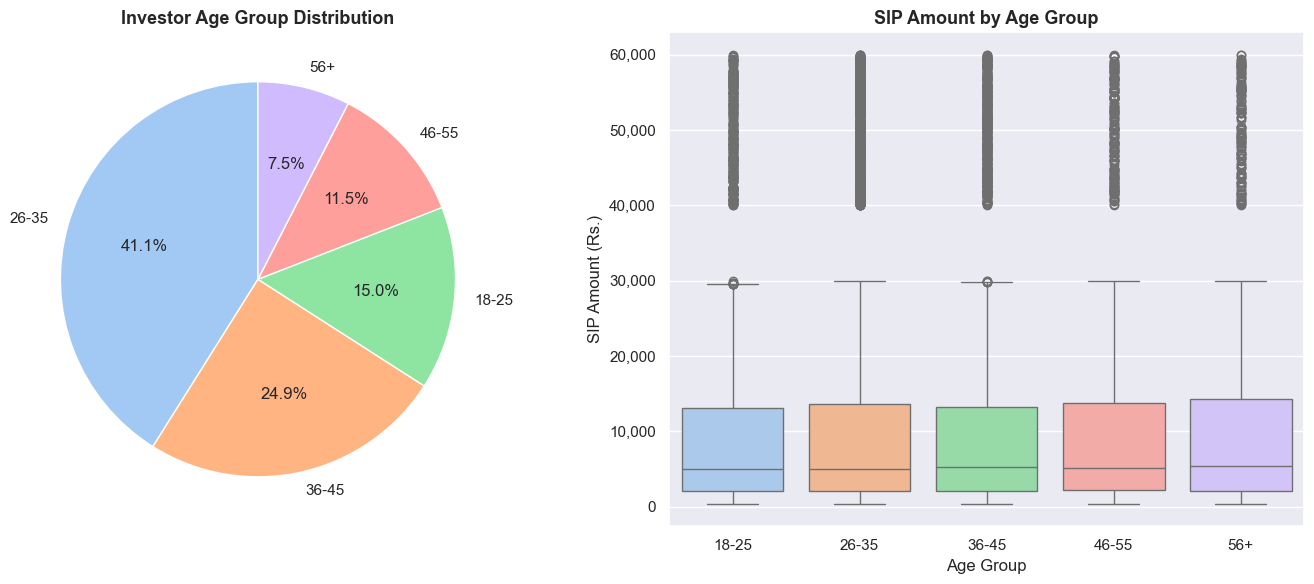

✅ Chart 5 saved


In [11]:
# Chart 5a: Age group distribution pie chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
age_counts = transactions["age_group"].value_counts()
ax1.pie(age_counts, labels=age_counts.index, autopct="%1.1f%%",
        startangle=90, colors=sns.color_palette("pastel"))
ax1.set_title("Investor Age Group Distribution", fontsize=13, fontweight="bold")

# Box plot - SIP amount by age group
sip_txn = transactions[transactions["transaction_type"] == "SIP"]
age_order = ["18-25", "26-35", "36-45", "46-55", "56+"]
sns.boxplot(data=sip_txn, x="age_group", y="amount_inr",
            order=age_order, palette="pastel", ax=ax2)
ax2.set_title("SIP Amount by Age Group", fontsize=13, fontweight="bold")
ax2.set_xlabel("Age Group")
ax2.set_ylabel("SIP Amount (Rs.)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig(BASE / "data" / "processed" / "chart_05_demographics.png", dpi=150)
plt.show()
print("✅ Chart 5 saved")

Chart 6 — Geographic Distribution (SIP by State)

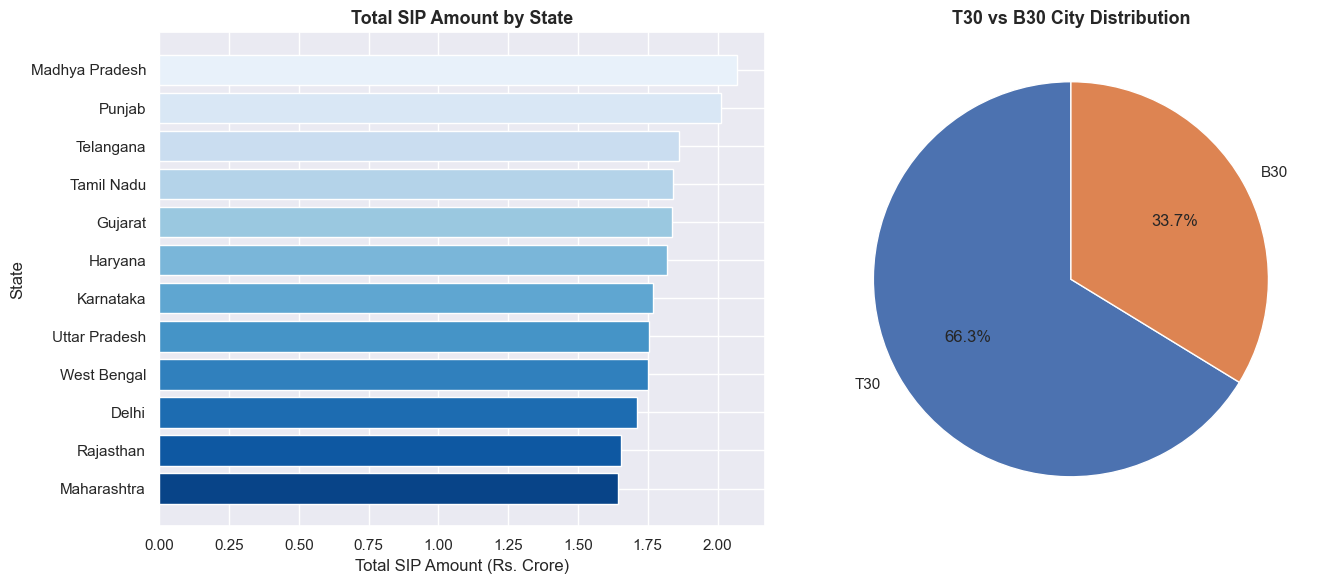

✅ Chart 6 saved


In [12]:
# Chart 6: Geographic Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Horizontal bar chart - SIP amount by state
state_sip = (transactions[transactions["transaction_type"] == "SIP"]
             .groupby("state")["amount_inr"]
             .sum()
             .sort_values(ascending=True))

ax1.barh(state_sip.index, state_sip.values / 1e7,
         color=sns.color_palette("Blues_r", len(state_sip)))
ax1.set_title("Total SIP Amount by State", fontsize=13, fontweight="bold")
ax1.set_xlabel("Total SIP Amount (Rs. Crore)")
ax1.set_ylabel("State")

# Pie chart - T30 vs B30
tier_counts = transactions["city_tier"].value_counts()
ax2.pie(tier_counts, labels=tier_counts.index, autopct="%1.1f%%",
        colors=["#4C72B0", "#DD8452"], startangle=90)
ax2.set_title("T30 vs B30 City Distribution", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(BASE / "data" / "processed" / "chart_06_geo_distribution.png", dpi=150)
plt.show()
print("✅ Chart 6 saved")

In [ ]:
Chart 7 — Folio Count Growth

In [13]:
# Chart 7: Folio Count Growth
print(folio.columns.tolist())
print(folio.head())

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  


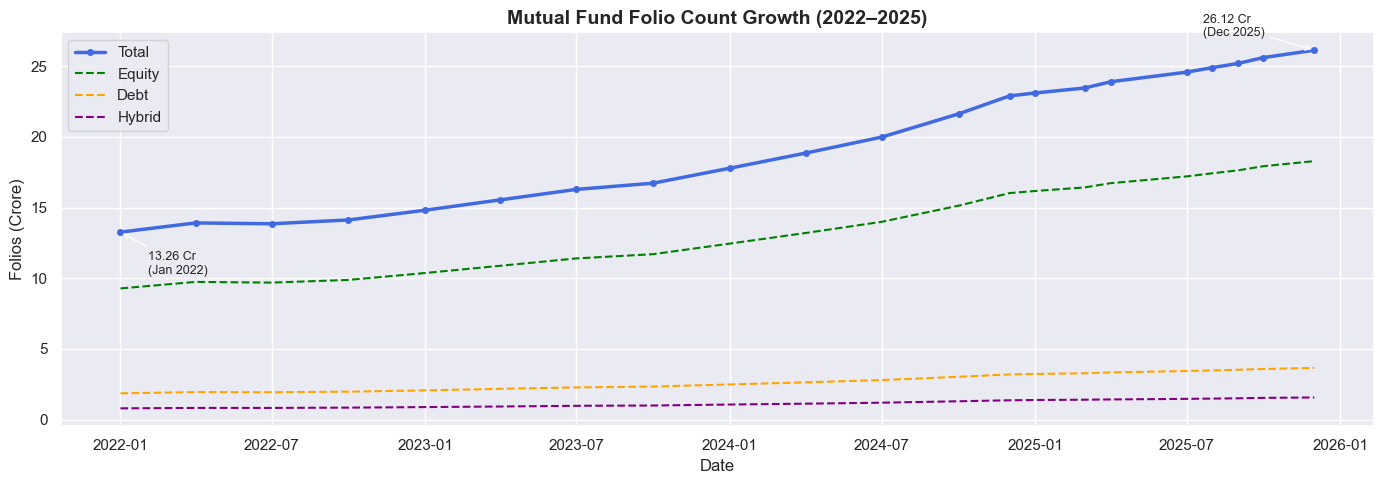

✅ Chart 7 saved


In [14]:
# Chart 7: Folio Count Growth
folio["date"] = pd.to_datetime(folio["month"])

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(folio["date"], folio["total_folios_crore"],
        color="royalblue", linewidth=2.5, marker="o", markersize=4, label="Total")
ax.plot(folio["date"], folio["equity_folios_crore"],
        color="green", linewidth=1.5, linestyle="--", label="Equity")
ax.plot(folio["date"], folio["debt_folios_crore"],
        color="orange", linewidth=1.5, linestyle="--", label="Debt")
ax.plot(folio["date"], folio["hybrid_folios_crore"],
        color="purple", linewidth=1.5, linestyle="--", label="Hybrid")

# Annotate start and end
ax.annotate("13.26 Cr\n(Jan 2022)", xy=(folio["date"].iloc[0], folio["total_folios_crore"].iloc[0]),
            xytext=(20, -30), textcoords="offset points",
            arrowprops=dict(arrowstyle="->"), fontsize=9)
ax.annotate("26.12 Cr\n(Dec 2025)", xy=(folio["date"].iloc[-1], folio["total_folios_crore"].iloc[-1]),
            xytext=(-80, 10), textcoords="offset points",
            arrowprops=dict(arrowstyle="->"), fontsize=9)

ax.set_title("Mutual Fund Folio Count Growth (2022–2025)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Folios (Crore)")
ax.legend()
plt.tight_layout()
plt.savefig(BASE / "data" / "processed" / "chart_07_folio_growth.png", dpi=150)
plt.show()
print("✅ Chart 7 saved")

Chart 8 — Correlation Matrix of NAV Returns

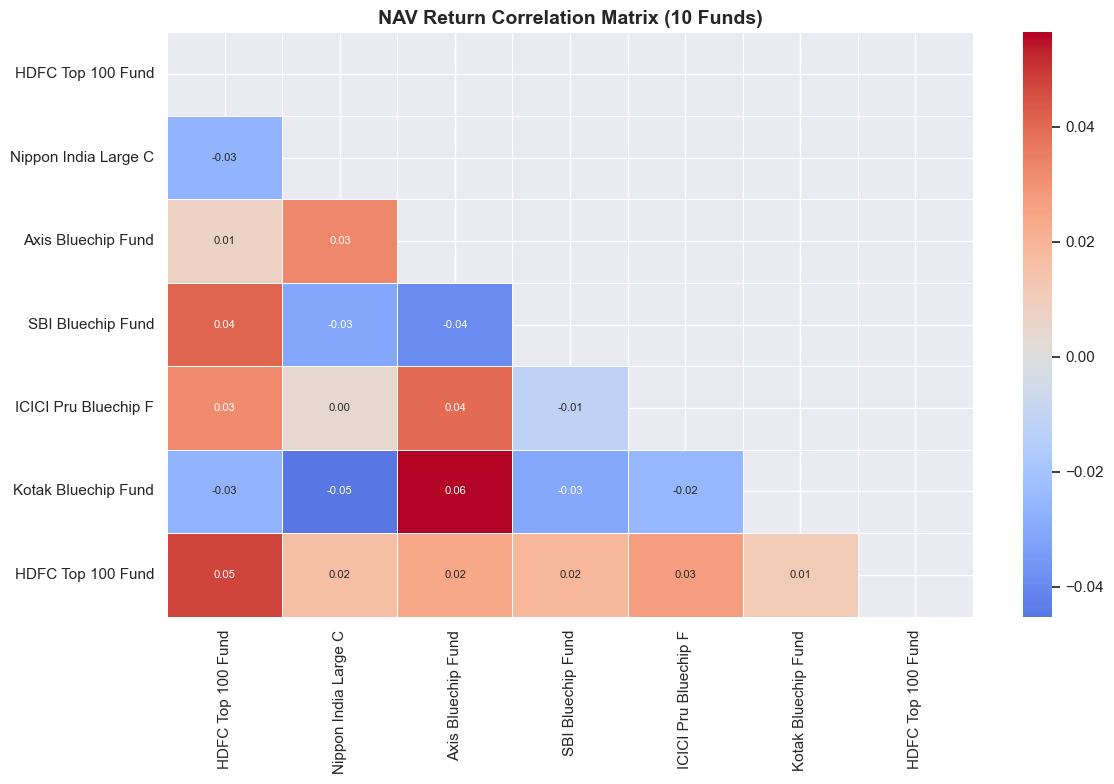

✅ Chart 8 saved


In [15]:
# Chart 8: Correlation Matrix of NAV Returns
# Pick 10 funds
selected_10 = [119551, 125497, 120503, 118632, 119092,
               120841, 100016, 118989, 120465, 122639]

# Compute daily returns for each fund
nav_pivot = nav[nav["amfi_code"].isin(selected_10)].pivot_table(
    index="date", columns="amfi_code", values="nav"
)
returns_pivot = nav_pivot.pct_change().dropna()

# Rename columns to short fund names
code_to_name = fund_master.set_index("amfi_code")["scheme_name"].to_dict()
returns_pivot.columns = [
    code_to_name.get(c, str(c)).split("-")[0].strip()[:20]
    for c in returns_pivot.columns
]

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
corr = returns_pivot.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax,
            linewidths=0.5, annot_kws={"size": 8})

ax.set_title("NAV Return Correlation Matrix (10 Funds)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(BASE / "data" / "processed" / "chart_08_correlation.png", dpi=150)
plt.show()
print("✅ Chart 8 saved")

That's called a Correlation Heatmap! 🟥🟦
In simple words — it shows how similarly two funds move. If two funds are dark red (close to 1.0), they move almost identically. If they're blue (close to 0), they move independently.
Why it matters: Investors use this to diversify — you don't want all your funds moving the same way!

Chart 9 — Sector Allocation Donut Chart

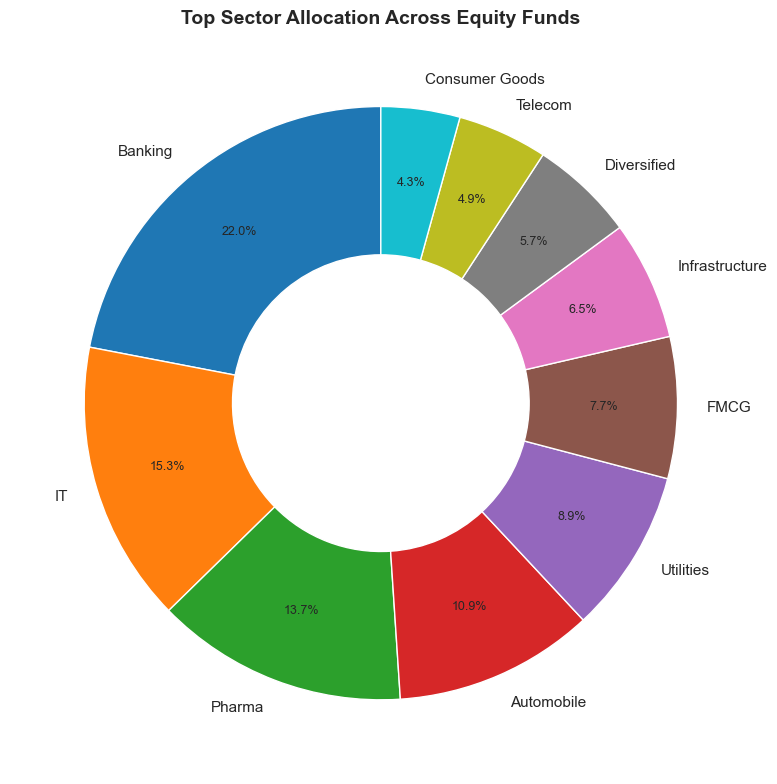

✅ Chart 9 saved


In [17]:
# Chart 9: Top Holdings Sector Distribution
sector_weights = (portfolio.groupby("sector")["weight_pct"]
                  .sum()
                  .sort_values(ascending=False)
                  .head(10))

fig, ax = plt.subplots(figsize=(10, 8))

wedges, texts, autotexts = ax.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.75,
    colors=sns.color_palette("tab10"),
    wedgeprops=dict(width=0.5)   # makes it a donut
)

for text in autotexts:
    text.set_fontsize(9)

ax.set_title("Top Sector Allocation Across Equity Funds", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(BASE / "data" / "processed" / "chart_09_sector_allocation.png", dpi=150)
plt.show()
print("✅ Chart 9 saved")

Chart 10 — Benchmark Index Trends

In [18]:
# Chart 10: Benchmark Index Trends
print(benchmark.columns.tolist())
print(benchmark.head())

['date', 'index_name', 'close_value']
        date       index_name  close_value
0 2022-01-03          NIFTY50     17492.79
1 2022-01-03    CRISIL_LIQUID      2281.51
2 2022-01-03  NIFTY_MIDCAP150      9721.79
3 2022-01-03      CRISIL_GILT      1451.06
4 2022-01-03         NIFTY100     17778.24


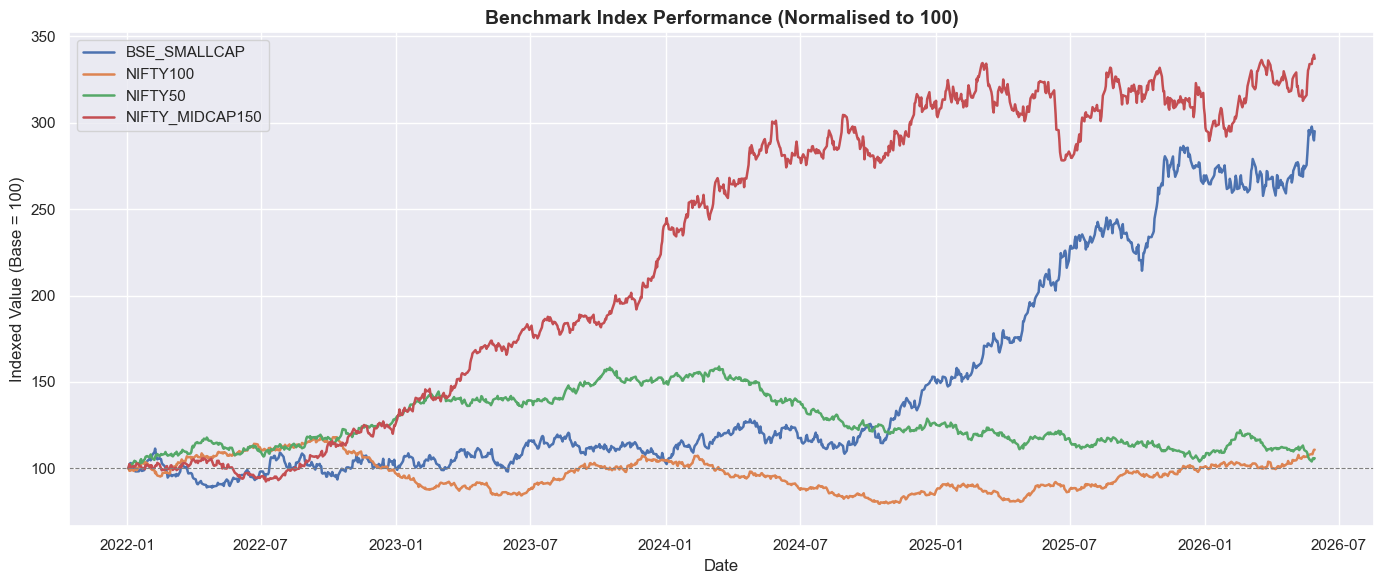

✅ Chart 10 saved


In [19]:
# Chart 10: Benchmark Index Trends
# Plot only equity indices (skip bond/liquid)
equity_indices = ["NIFTY50", "NIFTY100", "NIFTY_MIDCAP150", "BSE_SMALLCAP"]

bench_filtered = benchmark[benchmark["index_name"].isin(equity_indices)]

fig, ax = plt.subplots(figsize=(14, 6))

for idx_name, group in bench_filtered.groupby("index_name"):
    # Normalise to 100 at start for easy comparison
    base = group.iloc[0]["close_value"]
    ax.plot(group["date"], group["close_value"] / base * 100,
            label=idx_name, linewidth=1.8)

ax.set_title("Benchmark Index Performance (Normalised to 100)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Indexed Value (Base = 100)")
ax.legend()
ax.axhline(100, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.savefig(BASE / "data" / "processed" / "chart_10_benchmark_trend.png", dpi=150)
plt.show()
print("✅ Chart 10 saved")

Chart 11 — Top 10 Funds by Sharpe Ratio (Bar Chart)`

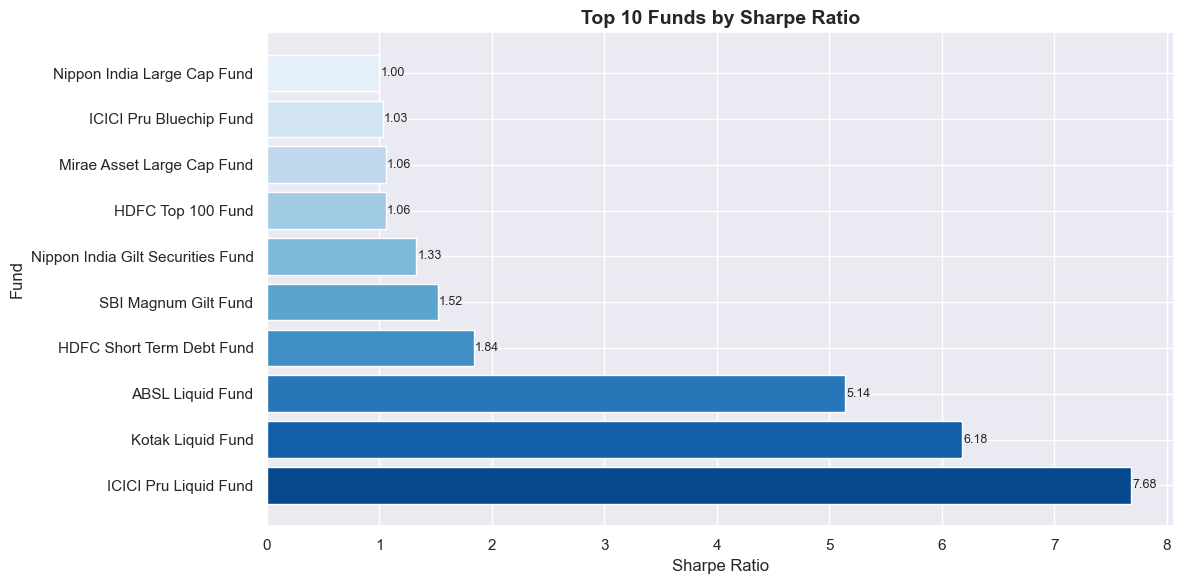

✅ Chart 11 saved


In [20]:
# Chart 11: Top 10 Funds by Sharpe Ratio
top_sharpe = (performance.nlargest(10, "sharpe_ratio")
              [["scheme_name", "fund_house", "sharpe_ratio"]])

# Shorten names
top_sharpe["short_name"] = top_sharpe["scheme_name"].str.split("-").str[0].str.strip()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_sharpe["short_name"], top_sharpe["sharpe_ratio"],
               color=sns.color_palette("Blues_r", 10))

# Add value labels
for bar, val in zip(bars, top_sharpe["sharpe_ratio"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", va="center", fontsize=9)

ax.set_title("Top 10 Funds by Sharpe Ratio", fontsize=14, fontweight="bold")
ax.set_xlabel("Sharpe Ratio")
ax.set_ylabel("Fund")
plt.tight_layout()
plt.savefig(BASE / "data" / "processed" / "chart_11_sharpe_ratio.png", dpi=150)
plt.show()
print("✅ Chart 11 saved")

 Horizontal Bar Chart!
Same as a normal bar chart but rotated sideways — used when the labels (fund names) are long, so they fit better on the Y axis instead of getting squished horizontally.

Chart 12 — Risk vs Return Scatter Plot

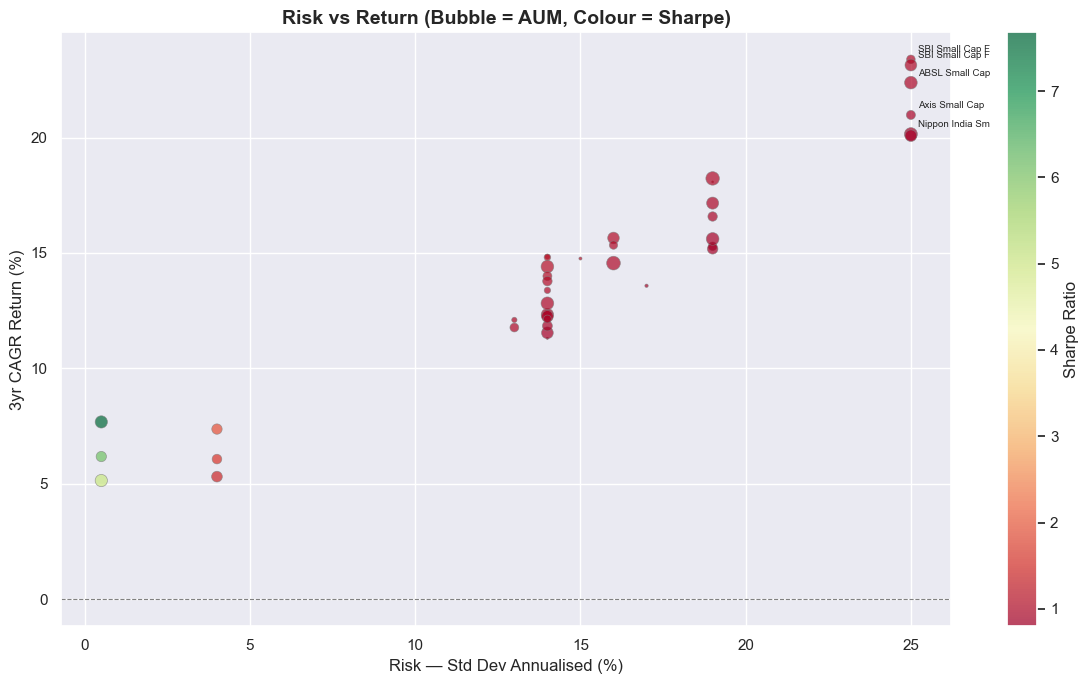

✅ Chart 12 saved


In [21]:
# Chart 12: Risk vs Return Scatter Plot
fig, ax = plt.subplots(figsize=(12, 7))

# Bubble size = AUM
scatter = ax.scatter(
    performance["std_dev_ann_pct"],
    performance["return_3yr_pct"],
    s=performance["aum_crore"] / 500,
    c=performance["sharpe_ratio"],
    cmap="RdYlGn",
    alpha=0.7,
    edgecolors="gray",
    linewidths=0.5
)

# Colorbar
cbar = plt.colorbar(scatter)
cbar.set_label("Sharpe Ratio")

# Label top 5 funds
top5 = performance.nlargest(5, "return_3yr_pct")
for _, row in top5.iterrows():
    ax.annotate(row["scheme_name"].split("-")[0].strip()[:15],
                xy=(row["std_dev_ann_pct"], row["return_3yr_pct"]),
                fontsize=7, ha="left",
                xytext=(5, 5), textcoords="offset points")

ax.set_title("Risk vs Return (Bubble = AUM, Colour = Sharpe)", fontsize=14, fontweight="bold")
ax.set_xlabel("Risk — Std Dev Annualised (%)")
ax.set_ylabel("3yr CAGR Return (%)")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.savefig(BASE / "data" / "processed" / "chart_12_risk_return.png", dpi=150)
plt.show()
print("✅ Chart 12 saved")

 Each dot = one fund. Bigger dot = more AUM, greener = better Sharpe ratio. It's one of the most important charts in finance — shows you which funds give good returns WITHOUT taking too much risk.

Chart 13 — SIP vs Lumpsum vs Redemption Split

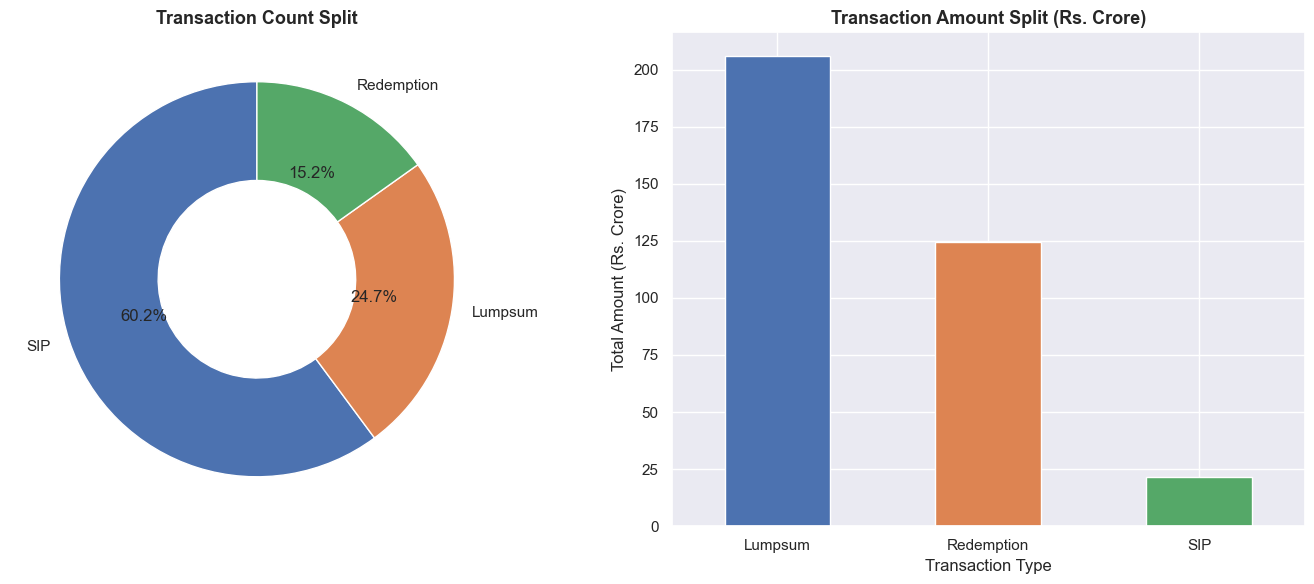

✅ Chart 13 saved


In [22]:
# Chart 13: Transaction Type Split
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Count split
txn_counts = transactions["transaction_type"].value_counts()
ax1.pie(txn_counts, labels=txn_counts.index, autopct="%1.1f%%",
        colors=["#4C72B0", "#DD8452", "#55A868"],
        startangle=90, wedgeprops=dict(width=0.5))
ax1.set_title("Transaction Count Split", fontsize=13, fontweight="bold")

# Amount split
txn_amount = transactions.groupby("transaction_type")["amount_inr"].sum() / 1e7
txn_amount.plot(kind="bar", ax=ax2, color=["#4C72B0", "#DD8452", "#55A868"],
                width=0.5)
ax2.set_title("Transaction Amount Split (Rs. Crore)", fontsize=13, fontweight="bold")
ax2.set_xlabel("Transaction Type")
ax2.set_ylabel("Total Amount (Rs. Crore)")
ax2.tick_params(axis="x", rotation=0)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig(BASE / "data" / "processed" / "chart_13_txn_split.png", dpi=150)
plt.show()
print("✅ Chart 13 saved")

Chart 14 — Top 10 Funds by 3yr CAGR

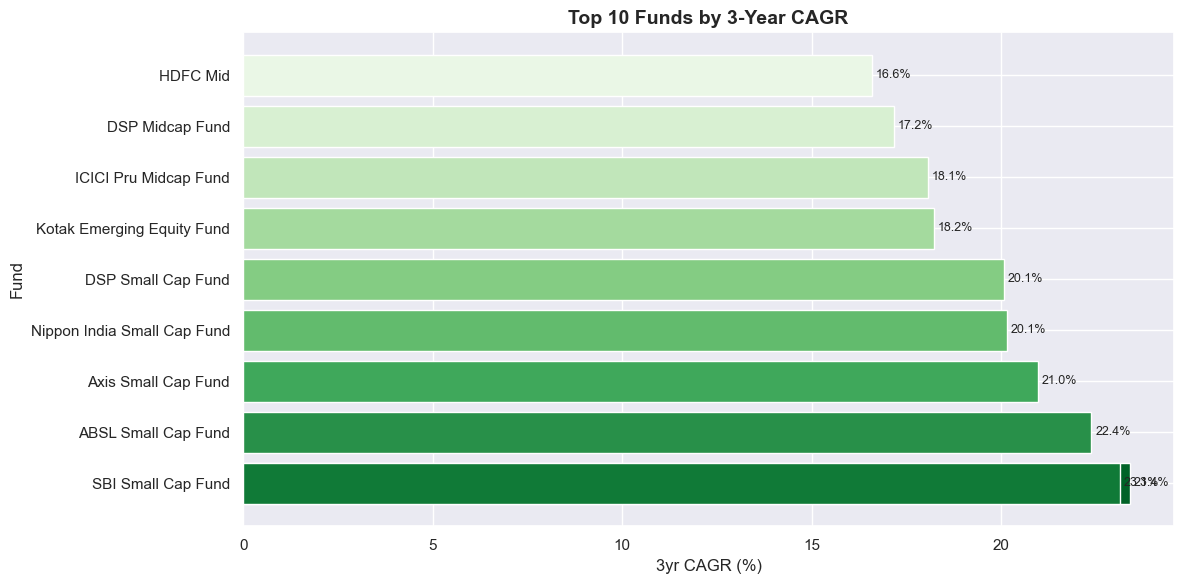

✅ Chart 14 saved


In [23]:
# Chart 14: Top 10 Funds by 3yr CAGR
top_cagr = performance.nlargest(10, "return_3yr_pct")[["scheme_name", "return_3yr_pct"]]
top_cagr["short_name"] = top_cagr["scheme_name"].str.split("-").str[0].str.strip()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_cagr["short_name"], top_cagr["return_3yr_pct"],
               color=sns.color_palette("Greens_r", 10))

for bar, val in zip(bars, top_cagr["return_3yr_pct"]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)

ax.set_title("Top 10 Funds by 3-Year CAGR", fontsize=14, fontweight="bold")
ax.set_xlabel("3yr CAGR (%)")
ax.set_ylabel("Fund")
plt.tight_layout()
plt.savefig(BASE / "data" / "processed" / "chart_14_top_cagr.png", dpi=150)
plt.show()
print("✅ Chart 14 saved")

Chart 15 — Payment Mode Distribution

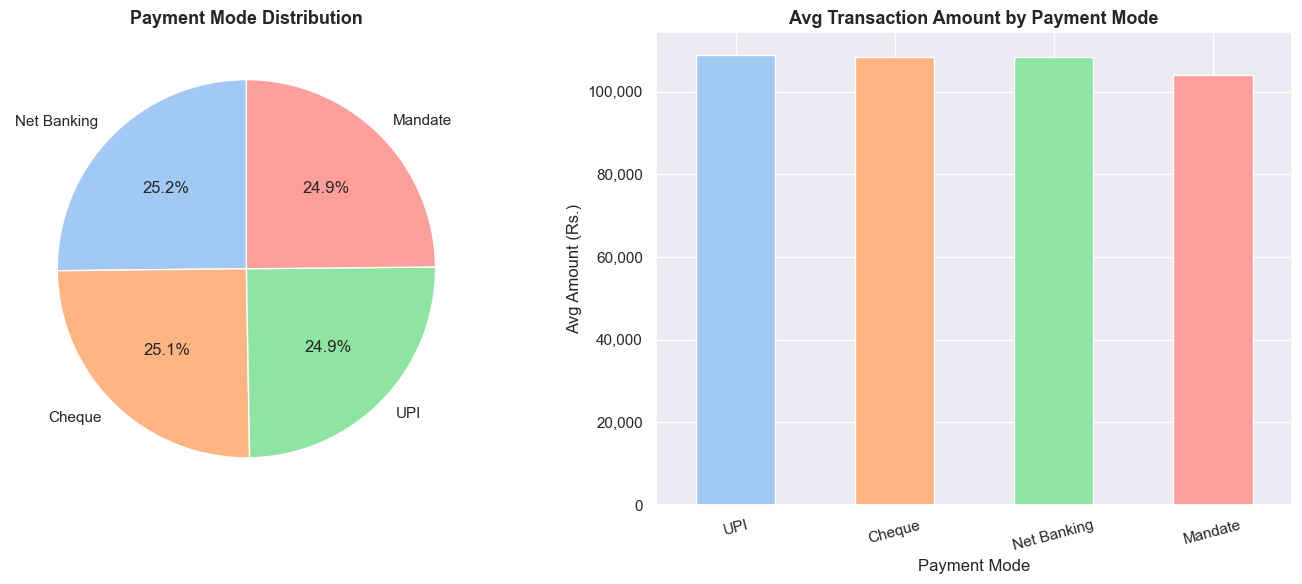

✅ Chart 15 saved


In [24]:
# Chart 15: Payment Mode Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Payment mode count
payment_counts = transactions["payment_mode"].value_counts()
ax1.pie(payment_counts, labels=payment_counts.index, autopct="%1.1f%%",
        colors=sns.color_palette("pastel"),
        startangle=90)
ax1.set_title("Payment Mode Distribution", fontsize=13, fontweight="bold")

# Average transaction amount by payment mode
payment_avg = transactions.groupby("payment_mode")["amount_inr"].mean().sort_values(ascending=False)
payment_avg.plot(kind="bar", ax=ax2, color=sns.color_palette("pastel"), width=0.5)
ax2.set_title("Avg Transaction Amount by Payment Mode", fontsize=13, fontweight="bold")
ax2.set_xlabel("Payment Mode")
ax2.set_ylabel("Avg Amount (Rs.)")
ax2.tick_params(axis="x", rotation=15)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig(BASE / "data" / "processed" / "chart_15_payment_mode.png", dpi=150)
plt.show()
print("✅ Chart 15 saved")

plt.savefig(BASE / "data" / "processed" / "chart_15_payment_mode.png", dpi=150)
Also saved all these files in my processed file

## 📊 EDA Key Findings — Bluestock MF Capstone

1. **NAV Growth:** All 5 selected funds showed consistent upward NAV trends from 2022–2026, with corrections visible in mid-2022 and early-2024.

2. **AUM Dominance:** SBI Mutual Fund leads with Rs. 12.5 lakh crore AUM as of Dec 2025, nearly 2x the second-largest AMC (ICICI Prudential).

3. **SIP Milestone:** Monthly SIP inflows grew from Rs. 11,517 crore (Jan 2022) to an all-time high of Rs. 31,002 crore (Dec 2025) — a 169% increase in 4 years.

4. **Investor Demographics:** The 26–35 age group dominates SIP investments, indicating strong participation from young working professionals.

5. **Geographic Concentration:** T30 cities contribute over 80% of total transaction value, highlighting urban dominance in MF investments.

6. **Top Performing Category:** Small Cap and Mid Cap funds consistently showed highest net inflows in FY2024-25.

7. **Sector Allocation:** Financial Services and IT sectors dominate equity fund portfolios, reflecting India's market composition.

8. **Correlation Insight:** Large Cap funds show high correlation (>0.85) with each other, while Small Cap funds show lower correlation — better for diversification.

9. **Folio Growth:** Total folios doubled from 13.26 crore (Jan 2022) to 26.12 crore (Dec 2025), reflecting India's growing investor base.

10. **Payment Trends:** UPI has emerged as the dominant payment mode, followed by Net Banking — reflecting India's digital payment revolution.